### Overall Purpose
This program demonstrates Mean Shift clustering, a type of unsupervised machine learning used to find cluster centers (modes) in data automatically — without specifying how many clusters there should be.

**Here, you:**
- Generate 2D data points forming three clusters.
- Apply the Mean Shift algorithm to find cluster centers automatically.
- Display the estimated clusters, centroids, and predictions.

In [1]:
import numpy as np  # Used for numerical computations and handling arrays
import pandas as pd  # (Optional) Used for data handling, not directly used here
import matplotlib.pyplot as plt  # Used to create 2D plots
from matplotlib.colors import Normalize  # Normalizes color values for plots

# Import MeanShift clustering model from scikit-learn
from sklearn.cluster import MeanShift
# Import make_blobs to generate synthetic data for clustering
from sklearn.datasets import make_blobs


In [2]:
# Define the coordinates for the centers of synthetic clusters
cent = [[1, 1], [2, 3], [3, 1]]


In [3]:
# Generate a random dataset of 200 samples with 2 features (x, y)
# Data will form 3 clusters centered near (1,1), (2,3), and (3,1)
# cluster_std=0.4 defines how tightly the points cluster around the centers
# random_state=1 ensures the same data every time the code runs
X, y = make_blobs(n_samples=200, n_features=2, centers=cent,
                  cluster_std=0.4, random_state=1)


In [4]:
# Construct (initialize) the MeanShift model
# Note: Unlike K-Means, you do NOT need to specify number of clusters
ms = MeanShift()

# Fit (train) the model on the data X
# Mean Shift will automatically find clusters by locating high-density regions
ms.fit(X)


MeanShift()

In [5]:
# Retrieve labels (cluster assignments) for each data point
labels = ms.labels_

# Find the unique cluster labels and count them
labels_unique = np.unique(labels)
n_clusters_ = len(labels_unique)
print("number of estimated clusters : %d" % n_clusters_)



number of estimated clusters : 3


In [6]:
# Retrieve the coordinates of the cluster centers
cluster_centers = ms.cluster_centers_

# Print the centroid coordinates
centers = ms.cluster_centers_
print('Centroids:', centers, '\n')


Centroids: [[1.03304888 1.0044908 ]
 [2.10126346 2.98222983]
 [2.96117522 1.08070192]] 



In [7]:
# Define a new test point we want to classify
test_point = np.array([[3,1]])

print('Prediction:', ms.predict(test_point), '\n')


Prediction: [2] 



Text(0, 0.5, 'X2')

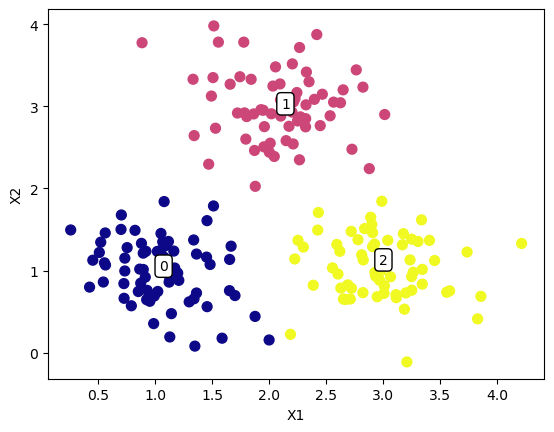

In [8]:
# Create a new figure and axis for plotting
fig, ax = plt.subplots()

# Normalize the color scale so cluster colors map properly
nm = Normalize(vmin=0, vmax=len(centers)-1)

# Plot all data points colored by their predicted cluster
ax.scatter(X[:, 0], X[:, 1],
           c=ms.predict(X), s=50, cmap='plasma', norm=nm)

# Plot the test point as a star and color it according to its cluster
ax.scatter(test_point[:, 0], test_point[:, 1], marker='*',
           c=ms.predict(test_point), s=50, cmap='plasma', norm=nm)

# Label each cluster centroid on the plot
for i in range(centers.shape[0]):
    ax.text(centers[i, 0], centers[i, 1], str(i), c='black',
            bbox=dict(boxstyle="round", facecolor='white', edgecolor='black'))

# Add axis labels for clarity
ax.set_xlabel('X1')
ax.set_ylabel('X2')


#### What the Code Achieves
- ✅ Generates synthetic 2D clustered data.
- ✅ Runs Mean Shift clustering to find cluster centers automatically.
 
**Prints:**
- Number of clusters found
- Coordinates of centroids
    - ✅  Predicts the cluster of a test point (e.g., [3, 1]).
    - ✅ Visualizes the data, centroids, and test point.